# Tarea 5. Modelos de Lenguaje Neuronales

Procesamiento de Lenguaje Natural 

Eric Lemus Avalos 

## 1. Modelo de Lenguaje Neuronal a nivel palabra 

In [1]:
# Librerias necesarias 
import os 
import time 
import math
import shutil 
import random 
from typing import Tuple 
from argparse import Namespace

import pandas as pd
import numpy as np  

from nltk import ngrams
from nltk.probability import FreqDist
from nltk.tokenize import TweetTokenizer, word_tokenize

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score

In [2]:
seed = 777
random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.benchmark = False #Ya que la entrada a la NN varia
torch.cuda.empty_cache()  

In [3]:
workdir = os.getcwd()
workdir

'C:\\Users\\ericl\\tareas_nlp\\tarea_5'

In [220]:
# Cargar los datosabs
def get_text_from_file(path_file: str, target_file: str) -> list:
    file_txt = []
    target_txt = []

    with open(path_file, 'r', encoding="utf8") as f_corpus, open(target_file, 'r', encoding="utf8") as f_target:
        for tweet in f_corpus:
            file_txt += [tweet]
        for target in f_target:
            target_txt += [target]
    
    file_txt = list(map(str.strip, file_txt))
    target_txt = list(map(int, target_txt))
    
    return file_txt, target_txt
    return file_txt, target_txt

X_train, _ = get_text_from_file("../tarea_2/data_mex/mex20_train.txt", "../tarea_2/data_mex/mex20_train_labels.txt")
X_val, _ = get_text_from_file("../tarea_2/data_mex/mex20_val.txt", "../tarea_2/data_mex/mex20_val_labels.txt")

In [221]:
print(len(X_train))
print(len(X_val))

5278
587


In [222]:
args = Namespace()
args.N = 4 #Secuencias del modelo hasta de tamano 4

### Embeddings preetrenados

In [7]:
import zipfile
path_w2v = r"C:\Users\ericl\Downloads\word2vec_col_nlp_class_spring_2023.zip"
with zipfile.ZipFile(path_w2v, 'r') as zip_ref:
    zip_ref.extractall('w2v')

In [8]:
import glob
from gensim.models import KeyedVectors

model_files = glob.glob(os.path.join('w2v', '*'))
w2v_file = model_files[0]

# Cargar el modelo word2vec
model = KeyedVectors.load_word2vec_format(w2v_file, binary=False, encoding='latin-1', unicode_errors='ignore')

# {palabra: vector}
embeddings_dict = {word: model[word] for word in model.index_to_key}

In [223]:
first_word = next(iter(embeddings_dict))
first_embedding = embeddings_dict[first_word]
embedding_dimension = first_embedding.shape[0]
print(f"Total de embeddings: {len(embeddings_dict)}")
print(f"Dimensión de cada embedding: {embedding_dimension}")
print(f"Ejemplo del primer embedding para la palabra '{first_word}':")
print(first_embedding)

Total de embeddings: 973265
Dimensión de cada embedding: 100
Ejemplo del primer embedding para la palabra 'de':
[-1.64168   1.447671 -2.283216 -1.965226 -0.222943  5.105217 -0.120701
 -0.126822 -3.177338 -3.454396 -0.943083 -0.094476 -1.18936  -0.812092
 -2.572975 -0.613877 -2.311841  1.05097   5.634725 -5.827006  1.237639
  1.071621  3.822072  2.395414  0.169883  3.256835  2.897348  3.274827
 -2.936382  0.272003 -1.029505 -2.617288 -1.807143  1.737624  0.33913
  3.93293   1.571361 -4.100074  4.156816  1.162366 -0.552316 -0.585887
 -4.767187  0.253338 -1.124162 -0.115079 -5.606624  2.976579  4.426022
  1.019932  3.76072  -2.298347  4.416567 -1.383988 -1.862506  0.399053
 -1.09689  -2.28599   2.992802  0.044008  3.762375 -6.523126  0.621278
  2.641829 -1.924327 -1.141184 -3.831767  0.549591  2.260839 -1.318358
 -1.134662 -3.788221 -0.775024  3.956695 -3.579425 -4.423733  4.505686
  0.719133 -1.399557  3.097209  0.107541  2.829867 -0.760249 -0.277246
 -1.225739  2.157902  0.518391  3.437

In [224]:
class NgramData():
    """
    NgramData procesa y transforma un corpus de texto en conjuntos de datos de n-gramas.
    - Tokeniza el texto y limpia tokens no deseados.
    - Construye un vocabulario limitado a las palabras más frecuentes.
    - Mapea palabras a identificadores numéricos y viceversa.
    - Genera representaciones numéricas de secuencias de palabras (n-gramas) para entrenamiento.

    Parámetros:
    - N: El tamaño del n-grama.
    - v_max: El tamaño máximo del vocabulario.
    - tokenizer: Función para tokenizar el texto.
    - pretrain_embedding: Diccionario con embeddings preentrenados {palabra: vector} (opcional).
    """
    def __init__(self, N: int, v_max: int = 5000, tokenizer = None, pretrain_embedding = None) -> None:
        self.N = N 
        self.v_max = v_max
        self.tokenizer = tokenizer if tokenizer else self.defaul_tokenizer
        self.punct = set(['#', 'http', 'https', 'www', '!', '?', '.', ',', 
                          ':', ';', '-', '_', '(', ')', '[', ']', '{', '}', 
                          '"', "'", '\n', '\t', '\r', '>', '<', '”', '...', '¿']) #'@usuario'])
        self.UNK = '<unk>'
        self.SOS = '<s>'
        self.EOS = '</s>'
        self.pretrain_embedding = pretrain_embedding

    def get_vocab_size(self) -> int:
        return len(self.vocab) 
    
    def defaul_tokenizer(self, doc: str) -> list: 
        return doc.split(' ')

    def remove_tokens(self, word: str) -> bool:
        return True if word.lower() in self.punct or word.isnumeric() else False

    def sorted_freqdict(self, fdic: FreqDist) -> list:
        aux = [key for key in fdic]
        aux.sort(key=lambda x: fdic[x], reverse=True)
        return aux
    
    def get_vocab(self, corpus: list) -> set:
        freq_dist = FreqDist([word.lower() for sentence in corpus\
                              for word in self.tokenizer(sentence)\
                              if not self.remove_tokens(word)])
        sorted_words = self.sorted_freqdict(freq_dist)[:self.v_max-3]
        return set(sorted_words)
    
    def fit(self, corpus: list) -> None: 
        # Construir el vocabulario a partir del corpus
        self.vocab = self.get_vocab(corpus)
        # Agregar tokens especiales
        self.vocab.add(self.UNK)
        self.vocab.add(self.SOS)
        self.vocab.add(self.EOS)

        # Diccionarios de mapeo: word2id e id2word
        self.word2id = {}
        self.id2word = {}

        if self.pretrain_embedding is not None:
            vector_size = next(iter(self.pretrain_embedding.values())).shape[0]
            self.embedding_matrix = np.empty([len(self.vocab), vector_size])
        
        id = 0 
        for doc in corpus: 
            for Word in self.tokenizer(doc): 
                word = Word.lower()
                if word in self.vocab and word not in self.word2id: 
                    self.word2id[word] = id
                    self.id2word[id] = word

                    # Si se disponen de embeddings preentrenados, asignar el vector correspondiente o uno aleatorio
                    if self.pretrain_embedding is not None:
                        if word in self.pretrain_embedding: 
                            self.embedding_matrix[id] = self.pretrain_embedding[word]
                        else: 
                            self.embedding_matrix[id] = np.random.rand(vector_size)
                    id += 1
                
        # Agregar tokens especiales al final
        self.word2id.update({
            self.UNK: id, 
            self.SOS: id+1,
            self.EOS: id+2
        })
        self.id2word.update({
            id: self.UNK, 
            id+1: self.SOS,
            id+2: self.EOS
        })

    def transform(self, corpus: list) -> Tuple[np.ndarray, np.ndarray]:
        X_ngrams = [] 
        y = []

        for doc in corpus:
            sentence = self.get_ngrams(doc)
            for word_window in sentence: 
                words_windows_ids = [self.word2id[w] for w in word_window]
                X_ngrams.append(list(words_windows_ids[:-1]))
                y.append(words_windows_ids[-1]) #utilizar la etiqueta n del n-grama de tamano n-1 como el target.
        
        return np.array(X_ngrams), np.array(y)

    def get_ngrams(self, doc: str) -> list: 
        doc_tokens = self.tokenizer(doc)
        doc_tokens = self.remplace_unk(doc_tokens)
        doc_tokens = [word.lower() for word in doc_tokens]
        doc_tokens = [self.SOS]*(self.N-1) + doc_tokens + [self.EOS]
        return list(ngrams(doc_tokens, self.N))
                
    def remplace_unk(self, doc_tokens: list) -> list:
        for i, token in enumerate(doc_tokens): 
            if token.lower() not in self.vocab: 
                doc_tokens[i] = self.UNK
        return doc_tokens


Utilizamos los embeddings preentrenados 

In [225]:
tk = TweetTokenizer()
ngram_data = NgramData(args.N, 13000, tk.tokenize, pretrain_embedding = embeddings_dict)
ngram_data.fit(X_train)

In [226]:
ngram_data.get_vocab_size()

13000

In [227]:
ngram_data.embedding_matrix.shape # (|V|, d_embedding)

(13000, 100)

In [228]:
list(ngram_data.vocab)[:10]

['#todoelmundomediceque',
 'incapacidad',
 'atrevida',
 'mensada',
 'true',
 'esté',
 'girardi',
 'tarda',
 'grité',
 'princesas']

In [229]:
w = ngram_data.word2id 
muestra_m = dict(list(w.items())[:10])
print(muestra_m)

{'@usuario': 0, 'q': 1, 'se': 2, 'puede': 3, 'esperar': 4, 'del': 5, 'maricon': 6, 'de': 7, 'closet': 8, 'la': 9}


In [230]:
# Trasformeamos los datos
X_ngram_train, y_ngram_train = ngram_data.transform(X_train)
X_ngram_val, y_ngram_val   = ngram_data.transform(X_val)

In [231]:
print(f'Shape of X_ngram_train: {X_ngram_train.shape}')
print(f'Shape of y_ngram_train: {y_ngram_train.shape}')

Shape of X_ngram_train: (102751, 3)
Shape of y_ngram_train: (102751,)


In [19]:
print(f'Shape of X_ngram_val: {X_ngram_val.shape}')
print(f'Shape of y_ngram_val: {y_ngram_val.shape}')

Shape of X_ngram_val: (11558, 3)
Shape of y_ngram_val: (11558,)


In [20]:
[[ngram_data.id2word[id] for id in lista] for lista in X_ngram_train[:20]]

[['<s>', '<s>', '<s>'],
 ['<s>', '<s>', '@usuario'],
 ['<s>', '@usuario', '@usuario'],
 ['@usuario', '@usuario', '@usuario'],
 ['@usuario', '@usuario', 'q'],
 ['@usuario', 'q', 'se'],
 ['q', 'se', 'puede'],
 ['se', 'puede', 'esperar'],
 ['puede', 'esperar', 'del'],
 ['esperar', 'del', 'maricon'],
 ['del', 'maricon', 'de'],
 ['maricon', 'de', 'closet'],
 ['de', 'closet', 'de'],
 ['closet', 'de', 'la'],
 ['de', 'la', 'yañez'],
 ['la', 'yañez', 'aun'],
 ['yañez', 'aun', 'recuerdo'],
 ['aun', 'recuerdo', 'esa'],
 ['recuerdo', 'esa', 'ves'],
 ['esa', 'ves', 'q']]

### **DataLoader** 

In [232]:
args.batch_size = 32
args.num_workers = 2

# Dataset 
train_dataset = TensorDataset(torch.tensor(X_ngram_train, dtype= torch.int64), 
                              torch.tensor(y_ngram_train, dtype= torch.int64))

val_dataset = TensorDataset(torch.tensor(X_ngram_val, dtype= torch.int64), 
                            torch.tensor(y_ngram_val, dtype= torch.int64))

# Loader 
train_loader =  DataLoader(train_dataset, 
                           batch_size = args.batch_size, 
                           num_workers = args.num_workers, 
                           shuffle = True, pin_memory=False)

valid_loader =  DataLoader(val_dataset, 
                         batch_size = args.batch_size, 
                         num_workers = args.num_workers, 
                         shuffle = False, pin_memory=False)

In [233]:
batch = next(iter(train_loader))
print(f'X shape: {batch[0].shape}')
print(f'y shape: {batch[1].shape}')

X shape: torch.Size([32, 3])
y shape: torch.Size([32])


In [234]:
muestra_batch = batch[0]
[[ngram_data.id2word[id] for id in lista] for lista in muestra_batch.tolist()][:20]

[['o', 'novia', 'como'],
 ['todo', 'está', 'de'],
 ['es', 'una', 'boda'],
 ['<s>', '@usuario', 'son'],
 ['ese', 'camote', '<unk>'],
 ['que', 'tienes', 'todo'],
 ['y', 'está', 'de'],
 ['tan', 'preocupante', 'como'],
 ['comestiquera', 'mi', 'gloss'],
 ['<unk>', 'pero', 'chingarse'],
 ['para', 'que', 'critiques'],
 ['#denuevotarde', 'jajaja', 'tengan'],
 ['cree', 'nada', '<unk>'],
 ['de', 'ser', 'feas'],
 ['miedo', 'pero', 'si'],
 ['pinches', 'hondureños', 'putos'],
 ['suben', 'al', '#transportepublico'],
 ['del', 'pan', 'y'],
 ['perra', 'como', 'lo'],
 ['enfurece', 'ver', 'que']]

In [235]:
muestra_batch = batch[1]
[ngram_data.id2word[id] for id in muestra_batch.tolist()][:10]

['mejor', 'la', 'si', 'unos', 'v', 'lo', 'chillón', 'que', '<unk>', 'el']

### **Modelo Neuronal de Bengio**

In [236]:
class NLM_Bengio(nn.Module): 
    def __init__(self, args, embedding=None):
        super(NLM_Bengio, self).__init__()
        self.window_size = args.N - 1
        self.embedding_size = args.d_embeddings
        
        if embedding is not None:
            # Se inicializa la capa de embedding con la matriz preentrenada.
            embedding_tensor = torch.FloatTensor(embedding)
            self.Embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=False)
        else:
            self.Embedding = nn.Embedding(args.vocab_size, args.d_embeddings)
        
        self.fc1 = nn.Linear(args.d_embeddings * self.window_size, args.d_h)
        self.drop1 = nn.Dropout(p=args.dropout)
        self.fc2 = nn.Linear(args.d_h, args.vocab_size, bias=False)

    def forward(self, x): 
        x = self.Embedding(x)
        # Se reorganiza la entrada para convertirla en un vector de dimensión window_size * embedding_size
        x = x.view(-1, self.window_size * self.embedding_size)
        h = F.relu(self.fc1(x))
        h = self.drop1(h)
        return self.fc2(h)





Funciones Utilices

In [214]:
# Obtener una distibucion de probabilidade de los logits 
def get_preds(raw_logits): 
    '''
    Funcion para obetener la distribucion de probabilidad de los logits del modelo 
    '''
    probs = F.softmax(raw_logits.detach(), dim = 1)
    y_pred = torch.argmax(probs, dim = 1).cpu().numpy()
    return y_pred


def model_eval(data,model, gpu = False):
    with torch.no_grad(): 
        preds, trgs = [], [] 
        for window_words, labels in data: 
            if gpu:
                window_words = window_words.cuda()

            outputs = model(window_words)

            # Get predictions 
            y_pre = get_preds(outputs)
            preds.append(y_pre)

            trg  = labels.numpy()
            trgs.append(trg)
    # Aplanar el batch 
    tgts = [e for l in trgs for e in l]
    preds = [e for l in preds for e in l]
            
    return accuracy_score(tgts,preds)


def save_checkpoint(state, is_best, checkpoint_patn, filename = 'checkpoint.pt'):
    '''Funcion para serializar objetos a disco y guardar ese objeto'''
    filename = os.path.join(checkpoint_patn, filename)
    torch.save(state, filename)
    if is_best: 
        shutil.copyfile(filename, os.path.join(checkpoint_patn, 'model_best.pt'))

def model_eval_loss(data, model, criterion, use_gpu=False):
    """
    Evalúa el loss promedio en el conjunto de datos.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for window_words, labels in data:
            if use_gpu:
                window_words = window_words.cuda()
                labels = labels.cuda()
            outputs = model(window_words)
            loss = criterion(outputs, labels)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
    return total_loss / total_samples if total_samples > 0 else 0

In [215]:
ngram_data.embedding_matrix

array([[ 0.82357894,  0.284633  ,  0.53534484, ...,  0.01932798,
         0.33368874,  0.22092278],
       [ 0.737638  , -1.81960106, -3.59204698, ..., -1.45375896,
         2.33609891,  5.81309223],
       [ 3.60493398, -0.31057501, -3.32116199, ...,  4.33534813,
         0.25759399,  3.24889112],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

### **Argumentos del modelo**

In [237]:
# Model hyperparameters
args.vocab_size = ngram_data.get_vocab_size()
args.d_embeddings = 100
args.d_h = 200
args.dropout = 0.1

# Train hyperparameters 
args.lr = 0.1
args.num_epochs = 45
args.patience = 20

# Scheduler hyperparameters 
args.lr_patience = 10
args.lr_factor = 0.5 

# save directory
args.savedir = 'model'
os.makedirs(args.savedir, exist_ok=True)


# Model
model = NLM_Bengio(args, ngram_data.embedding_matrix)

args.use_gpu = torch.cuda.is_available()
if args.use_gpu:
     model.cuda()
else:
     model.cpu() 

criterion = nn.CrossEntropyLoss()
optimizador = torch.optim.SGD(model.parameters(), lr = args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer = optimizador, mode = 'min', 
                                                      patience = args.lr_patience, 
                                                      verbose = True,  
                                                      factor = args.lr_factor) 

C:\Users\ericl\anaconda3\envs\nlp\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [238]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

### **Training**

In [218]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler,
                num_epochs, patience, use_gpu, savedir, get_preds, model_eval, save_checkpoint):
    start_time = time.time()
    best_metric = 0
    metric_history = []         # Historial de accuracy en validación
    train_metric_history = []   # Historial de accuracy en entrenamiento
    train_loss_history = []     # Historial de pérdida en entrenamiento
    valid_loss_history = []     # Historial de pérdida en validación
    n_no_improve = 0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        loss_epoch = []       # Pérdida por batch en entrenamiento
        training_metric = []  # Accuracy por batch en entrenamiento
        model.train()

        for window_words, labels in train_loader:
            if use_gpu:
                window_words = window_words.cuda()
                labels = labels.cuda()

            # Forward pass
            outputs = model(window_words)
            loss = criterion(outputs, labels)
            loss_epoch.append(loss.item())

            # Calcular accuracy para el batch
            y_pred = get_preds(outputs)
            tgt = labels.cpu().numpy()
            training_metric.append(accuracy_score(tgt, y_pred))

            # Backward pass y optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Promedio de loss y accuracy en entrenamiento para la época
        train_loss = np.mean(loss_epoch)
        mean_epoch_metric = np.mean(training_metric)
        train_loss_history.append(train_loss)
        train_metric_history.append(mean_epoch_metric)

        # Evaluación en el conjunto de validación
        tuning_metric = model_eval(valid_loader, model, gpu=use_gpu)
        valid_loss = model_eval_loss(valid_loader, model, criterion, use_gpu)
        metric_history.append(tuning_metric)
        valid_loss_history.append(valid_loss)

        # Actualizar scheduler basado en la métrica de validación
        scheduler.step(tuning_metric)

        # Verificar mejora en la métrica de validación
        is_improvement = tuning_metric > best_metric
        if is_improvement:
            best_metric = tuning_metric
            n_no_improve = 0
        else:
            n_no_improve += 1

        # Guardar checkpoint si hay mejora
        checkpoint = {
            "epoch": epoch + 1,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "best_metric": best_metric
        }
        save_checkpoint(checkpoint, is_improvement, savedir)

        # Early stopping
        if n_no_improve >= patience:
            print("No improvement. Breaking out of loop.")
            break

        print('Epoch [{}/{}], Train Loss: {:.4f} - Val Loss: {:.4f} - Train Acc: {:.4f} - Val Acc: {:.4f} - Epoch time: {:.2f}s'
              .format(epoch+1, num_epochs, train_loss, valid_loss, mean_epoch_metric, tuning_metric, (time.time() - epoch_start_time)))

    print("--- Total training time: {:.2f} seconds ---".format(time.time() - start_time))
    return best_metric, metric_history, train_metric_history, train_loss_history, valid_loss_history

In [239]:
best_metric, metric_history, train_metric_history, train_loss_history, valid_loss_history = train_model(
    model=model,
    train_loader=train_loader,     
    valid_loader=valid_loader,     
    criterion=criterion,
    optimizer=optimizador,
    scheduler=scheduler,
    num_epochs=args.num_epochs,
    patience=args.patience,
    use_gpu=args.use_gpu,
    savedir=args.savedir,
    get_preds=get_preds,           
    model_eval=model_eval,         
    save_checkpoint=save_checkpoint  
)

Epoch [1/45], Train Loss: 6.3458 - Val Loss: 5.3249 - Train Acc: 0.1243 - Val Acc: 0.1682 - Epoch time: 18.36s
Epoch [2/45], Train Loss: 5.8354 - Val Loss: 5.2054 - Train Acc: 0.1416 - Val Acc: 0.1777 - Epoch time: 21.32s
Epoch [3/45], Train Loss: 5.5881 - Val Loss: 5.2526 - Train Acc: 0.1450 - Val Acc: 0.1492 - Epoch time: 19.32s
Epoch [4/45], Train Loss: 5.3724 - Val Loss: 5.3348 - Train Acc: 0.1479 - Val Acc: 0.1323 - Epoch time: 18.45s
Epoch [5/45], Train Loss: 5.1755 - Val Loss: 5.3545 - Train Acc: 0.1489 - Val Acc: 0.1327 - Epoch time: 19.78s
Epoch [6/45], Train Loss: 4.9890 - Val Loss: 5.3559 - Train Acc: 0.1529 - Val Acc: 0.1510 - Epoch time: 18.61s
Epoch [7/45], Train Loss: 4.8085 - Val Loss: 5.4403 - Train Acc: 0.1549 - Val Acc: 0.1464 - Epoch time: 18.65s
Epoch [8/45], Train Loss: 4.6444 - Val Loss: 5.5066 - Train Acc: 0.1598 - Val Acc: 0.1469 - Epoch time: 18.75s
Epoch [9/45], Train Loss: 4.4963 - Val Loss: 5.6840 - Train Acc: 0.1675 - Val Acc: 0.1313 - Epoch time: 18.55s
E

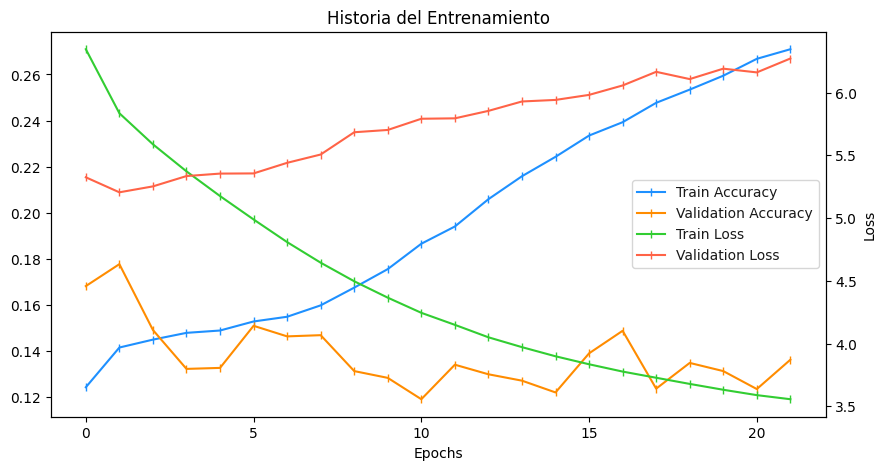

In [241]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(train_metric_history, label='Train Accuracy', marker='|', color='dodgerblue')  
ax1.plot(metric_history, label='Validation Accuracy', marker='|', color='darkorange') 
ax1.set_xlabel('Epochs')
ax1.tick_params(axis='y')
ax1.set_title('Historia del Entrenamiento')
ax2 = ax1.twinx()
ax2.plot(train_loss_history, label='Train Loss', marker='|', color='limegreen')  
ax2.plot(valid_loss_history, label='Validation Loss', marker='|', color='tomato') 
ax2.set_ylabel('Loss')
ax2.tick_params(axis='y')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines + lines2, labels + labels2, loc='center right')  # Leyenda en el centro derecho

for text in legend.get_texts():
    text.set_alpha(0.9)  

plt.show()


### **Top 10 palabras similares**

In [35]:
def print_closest_word(embedding,ngram_data, word, n):
     wors_id = torch.LongTensor([ngram_data.word2id[word]])
     word_embed = embedding(wors_id)
     distancia = torch.norm(embedding.weight - word_embed, dim = 1).detach()
     words_list = sorted(enumerate(distancia.numpy()), key = lambda x:x[1])
     for idx, diff in words_list[1:n+1]:
          print(ngram_data.id2word[idx], diff)

In [242]:
best_model = NLM_Bengio(args)
bets_model_path = r'model/model_best.pt'
best_model.load_state_dict(torch.load(bets_model_path)['state_dict'])
best_model.eval()

C:\Users\ericl\AppData\Local\Temp\ipykernel_29064\278898790.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(bets_model_path)['state

NLM_Bengio(
  (Embedding): Embedding(13000, 100)
  (fc1): Linear(in_features=300, out_features=200, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=200, out_features=13000, bias=False)
)

In [243]:
print('-'*20)
print('Learned Embeddings')
print('-'*20)
print_closest_word(best_model.Embedding, ngram_data, 'perro', 10)

--------------------
Learned Embeddings
--------------------
gato 9.551746
perrito 12.492241
cachorrito 16.959372
enano 17.2245
bicho 17.384398
gordo 17.411827
vecino 17.429192
macho 17.80732
sapo 17.826876
loro 18.232634


In [244]:
print('-'*20)
print('Learned Embeddings')
print('-'*20)
print_closest_word(best_model.Embedding, ngram_data, 'culo', 10)

--------------------
Learned Embeddings
--------------------
culito 17.313004
ojete 17.761541
trasero 18.5489
pene 18.642118
pito 18.677643
hocico 19.218496
osico 20.520056
orto 20.83457
bigote 21.438473
ogt 21.517197


In [245]:
print('-'*20)
print('Learned Embeddings')
print('-'*20)
print_closest_word(best_model.Embedding, ngram_data, 'presidente', 10)

--------------------
Learned Embeddings
--------------------
gobernador 11.981647
senador 13.4786625
diputado 14.398632
alcalde 14.423516
candidato 15.791155
pri 16.680422
representante 17.676867
magistrado 17.751913
secretario 18.278625
pp 18.676939


La mayoria de las palabras de embeddings mostrados para las palabras son bastante mejores, encontramos palabras que coocurren en el mismo contexto. Parece que el modelo logra aprender un poco como es la sintaxis del lenguaje. 

### **Generar Texto**

In [246]:
def parse_text(text, tokenizador): 
    '''Funcion para sacar los tokens del texto'''
    all_tokens = [w.lower() if w in ngram_data.word2id else '<unk>' for w in tokenizador.tokenize(text)]
    tokens_ids = [ngram_data.word2id[token.lower()] for token in all_tokens]
    return all_tokens, tokens_ids

def sample_next_word(logits, temperature=1.0): 
    logits = np.asarray(logits).astype('float64')
    preds = logits / temperature 
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds)
    return np.argmax(probas)

def predic_next_token(model, token_ids):
    word_ids_tensor = torch.LongTensor(token_ids).unsqueeze(0)
    y_raw_pred = model(word_ids_tensor).squeeze(0).detach().numpy()

    #y_probs = F.softmax(y_raw_pred, dim = 1)
    #y_pred = torch.argmax(y_probs, dim = 1).detach().numpy()

    y_pred = sample_next_word(y_raw_pred, 1.0)
    return y_pred


def generate_text(model, initial_text, tokenizador, n_pred = 100): 
    all_tokens, window_word_ids = parse_text(initial_text, tokenizador)

    for i in range(n_pred): 
        y_pred = predic_next_token(model,window_word_ids)
        next_word = ngram_data.id2word[y_pred]
        all_tokens.append(next_word)

        if next_word == '</s>':
            break 
        else: 
            window_word_ids.pop(0) #Eliminar el ultimo elemento
            window_word_ids.append(y_pred) 
    
    return ' '.join(all_tokens)

In [248]:
initial_text = '<s> arriba america'
print('-'*20)
print('Learned Embeddings')
print('-'*20)
generate_text(best_model,initial_text,tk)

--------------------
Learned Embeddings
--------------------


'<s> arriba america machorra <unk> de pinche otro abrazo <unk> y con mis semanas <unk> cayo mi gata <unk> <unk> matarrr diferente <unk> premier <unk> me llega a proteger a late el puto maestro <unk> pues que hacer esta enfermedad me vale hago mucho gordo <unk> dejenlas ejercicio y raya soñé idea de día con los que más todo el tiempo súper te ☝🏻 digo una ciudad más <unk> <unk> me casaban urgidos <unk> bajo mañana <unk> la gorda <unk> </s>'

In [250]:
initial_text = '<s> ya valio'
print('-'*20)
print('Learned Embeddings')
print('-'*20)
generate_text(best_model,initial_text,tk)

--------------------
Learned Embeddings
--------------------


'<s> ya valio verga <unk> </s>'

In [49]:
initial_text = 'hola mundo de'
print('-'*20)
print('Learned Embeddings')
print('-'*20)
generate_text(best_model,initial_text,tk)

--------------------
Learned Embeddings
--------------------


'hola mundo de esas personas <unk> porque la tanta drogan nunca son lo acuerdas porque y <unk> <unk> <unk> foreveralone </s>'

### **Likelihood de una oración**

In [251]:
def log_likelihood(model, text, ngram_data):
    # Genera una ventana de n-gram 
    X, y = ngram_data.transform([text])
    # Desechamos los dos primeros n-gramas ya que contienen el token '<s>'
    X, y = X[2:], y[2:]
    X = torch.LongTensor(X).unsqueeze(0)

    logits = model(X).detach()
    probs = F.softmax(logits, dim = 1).numpy()

    return np.sum([np.log(probs[i][w]) for i, w in enumerate(y)])

In [51]:
llh = log_likelihood(best_model,"el gobierno es una bola de corruptos", ngram_data)
print("log likelihood: ", llh)

log likelihood:  -31.204958


In [52]:
llh = log_likelihood(best_model,"grande sea el señor" , ngram_data)
print("log likelihood: ", llh)

log likelihood:  -15.515331


In [53]:
llh = log_likelihood(best_model,"csm el america", ngram_data)
print("log likelihood: ", llh)

log likelihood:  -10.96224


In [55]:
llh = log_likelihood(best_model,"hola mundo pequeño snoopy" , ngram_data)
print("log likelihood: ", llh)

log likelihood:  -14.641778


In [56]:
llh = log_likelihood(best_model,"disfruto lo malo, no solo lo nuevo" , ngram_data)
print("log likelihood: ", llh)

log likelihood:  -35.85128


### **Estructuras sintácticas correctas.**

In [253]:
from itertools import permutations

word_seq = "si pierde el america pierde mi familia".split(' ')

perms = {' '.join(perm) for perm in permutations(word_seq)}
perm_with_prob = [(log_likelihood(best_model, text, ngram_data), text) for text in perms]
sorted_perms = sorted(perm_with_prob, reverse=True)

print('-' * 20)
print("Top 5 permutaciones con mayor probabilidad de ser generadas:")
for p, t in sorted_perms[:5]:
    print(f"Log Likelihood: {p:.4f}, Texto: {t}")

print('-' * 20)
print("Top 5 permutaciones con menor probabilidad de ser generadas:")
for p, t in sorted_perms[-5:]:
    print(f"Log Likelihoo: {p:.4f}, Texto: {t}")

--------------------
Top 5 permutaciones con mayor probabilidad de ser generadas:
Log Likelihood: -30.4444, Texto: pierde america si el pierde mi familia
Log Likelihood: -30.7703, Texto: pierde pierde el america si mi familia
Log Likelihood: -32.8887, Texto: pierde pierde el america mi familia si
Log Likelihood: -33.1294, Texto: pierde pierde si el america mi familia
Log Likelihood: -33.4206, Texto: america pierde si el pierde mi familia
--------------------
Top 5 permutaciones con menor probabilidad de ser generadas:
Log Likelihoo: -61.3481, Texto: mi familia america pierde si pierde el
Log Likelihoo: -61.5060, Texto: mi el familia america pierde pierde si
Log Likelihoo: -61.6179, Texto: el si pierde mi familia america pierde
Log Likelihoo: -61.7412, Texto: si el mi pierde familia america pierde
Log Likelihoo: -62.9422, Texto: mi el familia america pierde si pierde


### **Perplejidad del modelo con Embeddings preentrendados**

In [255]:
def evaluate_perplexity(model, data_loader, criterion, device):
    model.eval()  
    total_loss = 0
    total_count = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item() * inputs.size(0)
            total_count += inputs.size(0)

    perplexity = np.exp(total_loss / total_count)
    return perplexity

In [256]:
device = torch.device("cuda" if args.use_gpu and torch.cuda.is_available() else "cpu")
val_perplexity = evaluate_perplexity(model, valid_loader, criterion, device)
print("Val Perplexity: {:.2f}".format(val_perplexity))

Val Perplexity: 529.41


#### **Modelo sin embeddings preetrenados**

In [257]:
ngram_data_NoPre = NgramData(args.N, 13000, tk.tokenize, pretrain_embedding = None)
ngram_data_NoPre.fit(X_train)
X_NoPre_ngram_train, y_NoPre_ngram_train = ngram_data_NoPre.transform(X_train)
X_NoPre_ngram_val, y_NoPre_ngram_val   = ngram_data_NoPre.transform(X_val)

In [258]:
args.batch_size = 32
args.num_workers = 2

train_dataset = TensorDataset(torch.tensor(X_NoPre_ngram_train, dtype= torch.int64), 
                              torch.tensor(y_NoPre_ngram_train, dtype= torch.int64))

val_dataset = TensorDataset(torch.tensor(X_NoPre_ngram_val, dtype= torch.int64), 
                            torch.tensor(y_NoPre_ngram_val, dtype= torch.int64))

# Loader 
train_loader =  DataLoader(train_dataset, 
                           batch_size = args.batch_size, 
                           num_workers = args.num_workers, 
                           shuffle = True, pin_memory=False)

valid_loader =  DataLoader(val_dataset, 
                         batch_size = args.batch_size, 
                         num_workers = args.num_workers, 
                         shuffle = False, pin_memory=False)

In [259]:
def save_checkpoint(state, is_best, checkpoint_patn, filename = 'checkpoint.pt'):
    '''Funcion para serializar objetos a disco y guardar ese objeto'''
    filename = os.path.join(checkpoint_patn, filename)
    torch.save(state, filename)
    if is_best: 
        shutil.copyfile(filename, os.path.join(checkpoint_patn, 'model_best.pt'))


In [260]:
# Model hyperparameters
args.vocab_size = ngram_data_NoPre.get_vocab_size()
args.d_embeddings = 100
args.d_h = 200
args.dropout = 0.1

# Train hyperparameters 
args.lr = 2.3e-1
args.num_epochs = 100
args.patience = 20

# Scheduler hyperparameters 
args.lr_patience = 10
args.lr_factor = 0.5 

# save directory
args.savedir = 'model_NoPre'
os.makedirs(args.savedir, exist_ok=True)


# Model
model = NLM_Bengio(args, None)

args.use_gpu = torch.cuda.is_available()
if args.use_gpu:
     model.cuda()
else:
     model.cpu() 

criterion = nn.CrossEntropyLoss()
optimizador = torch.optim.SGD(model.parameters(), lr = args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer = optimizador, mode = 'min', 
                                                      patience = args.lr_patience, 
                                                      verbose = True,  
                                                      factor = args.lr_factor) 

C:\Users\ericl\anaconda3\envs\nlp\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [261]:
best_metric, metric_history, train_metric_history, train_loss_history, valid_loss_history  = train_model(
    model=model,
    train_loader=train_loader,     
    valid_loader=valid_loader,     
    criterion=criterion,
    optimizer=optimizador,
    scheduler=scheduler,
    num_epochs=args.num_epochs,
    patience=args.patience,
    use_gpu=args.use_gpu,
    savedir=args.savedir,
    get_preds=get_preds,           
    model_eval=model_eval,         
    save_checkpoint=save_checkpoint  
)

Epoch [1/100], Train Loss: 6.3566 - Val Loss: 5.4884 - Train Acc: 0.1129 - Val Acc: 0.1183 - Epoch time: 17.94s
Epoch [2/100], Train Loss: 5.8253 - Val Loss: 5.3042 - Train Acc: 0.1314 - Val Acc: 0.1408 - Epoch time: 19.71s
Epoch [3/100], Train Loss: 5.5200 - Val Loss: 5.3714 - Train Acc: 0.1374 - Val Acc: 0.1302 - Epoch time: 20.04s
Epoch [4/100], Train Loss: 5.2432 - Val Loss: 5.3750 - Train Acc: 0.1417 - Val Acc: 0.1437 - Epoch time: 20.04s
Epoch [5/100], Train Loss: 4.9875 - Val Loss: 5.3630 - Train Acc: 0.1459 - Val Acc: 0.1512 - Epoch time: 19.35s
Epoch [6/100], Train Loss: 4.7361 - Val Loss: 5.6111 - Train Acc: 0.1500 - Val Acc: 0.1225 - Epoch time: 18.73s
Epoch [7/100], Train Loss: 4.4971 - Val Loss: 5.6864 - Train Acc: 0.1574 - Val Acc: 0.1281 - Epoch time: 18.38s
Epoch [8/100], Train Loss: 4.2754 - Val Loss: 5.7473 - Train Acc: 0.1722 - Val Acc: 0.1261 - Epoch time: 18.62s
Epoch [9/100], Train Loss: 4.0717 - Val Loss: 5.9121 - Train Acc: 0.1958 - Val Acc: 0.1254 - Epoch time:

In [262]:
val_perplexity = evaluate_perplexity(model, valid_loader, criterion, device)
print("Val Perplexity: {:.2f}".format(val_perplexity))

Val Perplexity: 1024.11


El uso de embeddings preentrenados estáticos evita la dependencia del contexto. El modelo con embeddings preentrenados muestra menor perplejidad (**529.41** respecto a **1024.11**), el modelo con embeddings preentrenados no se queda tan perplejo al predecir la etiqueta de una entrada que no vio en el entrenamiento. El acurracy para el de embeddigs preentrenados **accuracy (0.2668)** fue inferior al modelo que no utilizó embeddings preentrenados **accuracy (0.4567)**.

#### **Modelo probabilista**

Consideramos una modificacion el modelo probabilista implementado en la práctica 4, para que tambien sea un modelo de tetagramas. 


In [66]:
txt_train, txt_y = get_text_from_file("../tarea_2/data_mex/mex20_train.txt", "../tarea_2/data_mex/mex20_train_labels.txt")
tokenizer = TweetTokenizer()
corpus = []
for doc in txt_train:
    corpus += ["<s>"] + ["<s>"] + ["<s>"] + tokenizer.tokenize(doc) + ["</s>"] 

In [70]:

class TetagramData:
    
    def __init__(self, vocab_max: int, tk: TweetTokenizer):  
        self.vocab_max = vocab_max
        self.tk = tk
        self.UNK = "<unk>"
        self.EOS = "</s>"
        self.SOS = "<s>"
        self.final_vocab = set()
    
    def fit(self, raw_tokens: list) -> list:
        freq_dist = FreqDist()
        tokenized_corpus = []
        
        # Tokenizar tweets
        for txt in raw_tokens: 
            tokens = self.tk.tokenize(txt)
            tokenized_corpus.append(tokens)  # Guardar lista de tokens
            
            # Contar cada palabra en el vocabulario
            for word in tokens:  
                freq_dist[word] += 1  
        
        # Truncar el vocab a vocab_max
        self.final_vocab = {tok for tok,_ in freq_dist.most_common(self.vocab_max)}
        
        # Agregar tokens especiales
        self.final_vocab.update([self.UNK, self.SOS, self.EOS])
        
        transformed_corpus = [] 
        for tokens in tokenized_corpus:
            transformed_corpus.append(self.transform(tokens))
        
        return transformed_corpus 
        
    def mask_oov(self, word: str) -> str:
        return self.UNK if word not in self.final_vocab else word
        
    def add_sos_eos(self, tokens: list) -> list:
        return [self.SOS, self.SOS, self.SOS] + tokens + [self.EOS]
        
    def transform(self, tokens: list) -> list:
        transformed = []
        for word in tokens:
            transformed.append(self.mask_oov(word))  
        return self.add_sos_eos(transformed)  


In [71]:
from typing import List, Tuple
class TetagramaPLM:

    def __init__(self, lambda1 = 0.4, lambda2 = 0.6, lambda3 = 0.1, lambda4 = 0.1):
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.lambda3 = lambda3
        self.lambda4 = lambda4

        #contadores
        self.unigram_counts = {}
        self.bigram_counts  = {}
        self.trigram_counts = {}
        self.tetagram_counts = {}

        self.vocab = 0
        self.total_tokes = 0
        self.V = 0

    def train(self, transformed_corpus, final_vocabulary):
        self.vocab =  final_vocabulary
        self.V = len(final_vocabulary)

        for tokens in transformed_corpus:
            for i, w in enumerate(tokens):

                #Unigrams 
                self.unigram_counts[w] = self.unigram_counts.get(w,0) + 1
                
                #Bigrams 
                if i >0: 
                    w_prev = tokens[i-1]
                    self.bigram_counts[(w_prev,w)] = self.bigram_counts.get((w_prev,w),0) + 1 
                
                #Trigams 
                if i > 1: 
                    w_prev_prev = tokens[i-2]
                    self.trigram_counts[(w_prev_prev, w_prev, w)] = \
                        self.trigram_counts.get((w_prev_prev, w_prev, w),0) + 1 

                if i > 2:
                    w_prev3 = tokens[i-3]
                    self.tetagram_counts[(w_prev3, w_prev_prev, w_prev, w)] = \
                        self.tetagram_counts.get((w_prev3, w_prev_prev, w_prev, w), 0) + 1 

                    
                        
        self.total_tokes = sum(self.unigram_counts.values())


    def mask_oov(self, word):
        return "<unk>" if word not in self.vocab else word

    def unigram_probability(self, w):
        return (self.unigram_counts.get(self.mask_oov(w), 0) + 1) / (self.total_tokes + self.V) 

    def bigram_probability(self, w_prev, w):
        numerador = self.bigram_counts.get((self.mask_oov(w_prev), self.mask_oov(w)), 0) + 1
        denominador = self.total_tokes + self.V
        return  numerador / denominador
        
    def trigram_probability(self, w_prev_prev, w_prev, w):
        numerador = self.trigram_counts.get((self.mask_oov(w_prev_prev), self.mask_oov(w_prev), self.mask_oov(w)), 0) + 1
        denominador = self.total_tokes + self.V
        return  numerador / denominador

    def tetagram_probability(self, w_prev3, w_prev_prev, w_prev, w): 
        numerador = self.tetagram_counts.get((self.mask_oov(w_prev3), self.mask_oov(w_prev_prev), self.mask_oov(w_prev), self.mask_oov(w)), 0 ) + 1
        denomidador = self.total_tokes + self.V
        return numerador / denomidador

    def probability_word(self, w_prev3, w_prev_prev, w_prev, w):
        term_1 = self.lambda1 * self.unigram_probability(w)
        term_2 = self.lambda2 * self.bigram_probability(w_prev, w)
        term_3 = self.lambda3 * self.trigram_probability(w_prev_prev, w_prev, w)
        term_4 = self.lambda4 * self.tetagram_probability(w_prev3, w_prev_prev, w_prev, w)
        return  term_1 + term_2 + term_3 +term_4

    #Modificar para que tome en cuanta los tetagramas
    def seq_probability(self,sequence):
        log_p = 0.0
        for i in range(len(sequence)):
            w_prev3 = sequence[i-3] if i >= 3 else "<s>"
            w_prev_prev = sequence[i-2] if i >= 2 else "<s>"
            w_prev = sequence[i-1] if i >= 1 else "<s>"
            w = sequence[i]
            p = self.probability_word(w_prev_prev, w_prev, w)
            log_p += math.log(p)
        return math.exp(log_p)
   
    def check_probas(self):
        return sum(self.unigram_probability(w) for w in self.vocab)

    def top_k_next_words(self, words: List[str], top: int) -> List[Tuple[str, float]]:
        candidates = {}
        w_prev3, w_prev_prev, w_prev = words[-3], words[-2], words[-1]
        
        for word in self.vocab:
            prob = self.probability_word(w_prev_prev, w_prev, word)
            candidates[word] = prob
        
        return sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:top]

    def calc_perplexity(self, sequence: List[str]) -> float:
        N = len(sequence)
        log_prob_sum = sum(math.log(self.probability_word(sequence[i - 3], sequence[i - 2], sequence[i - 1], sequence[i])) for i in range(3, N))
        return math.exp(log_prob_sum / N)

    def generate_text(self, words: List[str], max_length: int) -> str:
        generated = words[:]
        for _ in range(max_length - len(words)):
            top_next = self.top_k_next_words(generated, top=1000)
            if not top_next:
                break
            next_word = random.choices([w for w, _ in top_next], weights=[p for _, p in top_next])[0]
            generated.append(next_word)
            if next_word == "</s>":
                break
        return " ".join(generated)


    def rank_permutation(self, test_tokens: list, top_k: int, botton_k: int):
        from itertools import permutations
        permuted_sequences = list(permutations(test_tokens))
        
        scored_sequences = [(seq, self.seq_probability(seq)) for seq in permuted_sequences]
        scored_sequences.sort(key=lambda x: x[1], reverse=True)
        
        top_sequences = scored_sequences[:top_k]
        bottom_sequences = scored_sequences[-botton_k:]
        
        return top_sequences, bottom_sequences

        

In [72]:
tk = TweetTokenizer()
tetagram_data = TetagramData(vocab_max=13000, tk=tk)
transformed_corpus = tetagram_data.fit(txt_train)
final_vacab =  tetagram_data.final_vocab

In [73]:
tetagram_lm = TetagramaPLM(lambda1=0, lambda2=6, lambda3=1.0, lambda4=0.1)
tetagram_lm.train(transformed_corpus, final_vacab)

In [74]:
def calculate_perplexity_on_validation_set(tetagram_lm, txt_val, tokenizer):
    """
    Calcula la perplejidad del modelo TetagramaPLM sobre un conjunto de validación completo.
    """
    total_log_prob = 0.0
    total_length = 0

    for doc in txt_val:
        tokens = ["<s>", "<s>", "<s>"] + tokenizer.tokenize(doc) + ["</s>"]
        
        # Calcula la probabilidad logarítmica de la secuencia
        if len(tokens) >= 4: 
            log_prob = 0.0
            # Calcular la probabilidad logarítmica para cada tetragrama en el documento
            for i in range(3, len(tokens)):
                w_prev3 = tokens[i-3]
                w_prev2 = tokens[i-2]
                w_prev1 = tokens[i-1]
                w = tokens[i]
                prob = tetagram_lm.probability_word(w_prev3, w_prev2, w_prev1, w)
                log_prob += math.log(prob) if prob > 0 else -math.inf  
            total_log_prob += log_prob
            total_length += (len(tokens) - 3)  # No contar los tokens de inicio en la longitud

    
    if total_length > 0:
        average_log_prob = total_log_prob / total_length
        perplexity = math.exp(-average_log_prob)
        return perplexity
    else:
        return float('inf')  

txt_val, y_val = get_text_from_file("../tarea_2/data_mex/mex20_val.txt", "../tarea_2/data_mex/mex20_val_labels.txt")
tokenizer = TweetTokenizer()
perplexity = calculate_perplexity_on_validation_set(tetagram_lm, txt_val, tokenizer)
print("Val Perplexity: {:.2f}".format(perplexity))

Val Perplexity: 3000.64


Comparado con el modelo probabílistico obtenemos una perplejidad mayor (**3000.64**), aunque el tiempo de ejecución es mucho menor que al del modelo neuronal ya se con o sin embeddings preentrenados. 

## 2. Modelo de Lenguaje Neuronal a nivel carácter 

In [368]:
class CharNgramData:
    """
    CharNgramData procesa y transforma un corpus de texto en conjuntos de datos de n-gramas a nivel de caracteres.
    - Tokeniza el texto en caracteres y limpia tokens no deseados.
    - Construye un vocabulario de caracteres.
    - Mapea caracteres a identificadores numéricos y viceversa.
    - Genera representaciones numéricas de secuencias de caracteres (n-gramas) para entrenamiento.
    
    Parámetros:
    - N: El tamaño del n-grama.
    - v_max: El tamaño máximo del vocabulario.
    - tokenizer: Función para tokenizar el texto a nivel de caracteres (opcional).
    - pretrain_embedding: Diccionario con embeddings preentrenados {carácter: vector} (opcional).
    - allowed_chars_file: Ruta al archivo que contiene los caracteres permitidos.
    """
    def __init__(self, N: int, v_max: int = 50, tokenizer=None, pretrain_embedding=None, allowed_chars_file: str = 'caracteres.txt') -> None:
        self.N = N 
        self.v_max = v_max
        self.allowed_chars = self.load_allowed_chars(allowed_chars_file)
        self.UNK = '<unk>'
        self.SOS = '<s>'
        self.EOS = '</s>'
        self.pretrain_embedding = pretrain_embedding
        self.char_tokenizer = tokenizer if tokenizer else self.default_tokenizer

    def load_allowed_chars(self, file_path: str) -> set:
        """
        Carga el conjunto de caracteres permitidos desde un archivo.
        Cada línea del archivo debe contener un único carácter.
        """
        with open(file_path, encoding='utf-8') as f:
            return set(line.strip() for line in f if line.strip())

    def default_tokenizer(self, doc: str) -> List[str]:
        # Tokeniza a nivel de caracteres utilizando word_tokenize para segmentar en "palabras"
        # y luego descomponiendo cada palabra en caracteres
        return [char for word in word_tokenize(doc) for char in word]

    def remove_char(self, char: str) -> bool:
        # Devuelve True si el carácter NO está en el conjunto de caracteres permitidos.
        return char not in self.allowed_chars

    def sorted_freqdict(self, fdic: FreqDist) -> list:
        aux = [key for key in fdic]
        aux.sort(key=lambda x: fdic[x], reverse=True)
        return aux
    
    def get_vocab(self, corpus: list) -> set:
        freq_dist = FreqDist(
            [char for sentence in corpus for char in self.char_tokenizer(sentence)
             if not self.remove_char(char)]
        )
        sorted_chars = self.sorted_freqdict(freq_dist)[:self.v_max-3]
        return set(sorted_chars) 
    
    def fit(self, corpus: list) -> None:
        # Construir el vocabulario a partir del corpus
        self.vocab = self.get_vocab(corpus)
        # Agregar tokens especiales
        self.vocab.add(self.UNK)
        self.vocab.add(self.SOS)
        self.vocab.add(self.EOS)

        # Diccionarios de mapeo: char2id e id2char
        self.char2id = {}
        self.id2char = {}

        # Inicializar la matriz de embeddings si se proporcionan embeddings preentrenados
        if self.pretrain_embedding is not None:
            sample_vector = next(iter(self.pretrain_embedding.values()))
            vector_size = sample_vector.shape[0] if hasattr(sample_vector, 'shape') else len(sample_vector)
            self.embedding_matrix = np.empty([len(self.vocab), vector_size])
         
        id = 0
        # Iterar sobre el corpus y llenar los diccionarios con cada carácter
        for doc in corpus:
            for char in self.char_tokenizer(doc):
                if char in self.vocab and char not in self.char2id:
                    self.char2id[char] = id
                    self.id2char[id] = char

                    # Si se tienen embeddings preentrenados, asignar el vector correspondiente o uno aleatorio
                    if self.pretrain_embedding is not None:
                        if char in self.pretrain_embedding:
                            self.embedding_matrix[id] = self.pretrain_embedding[char]
                        else:
                            self.embedding_matrix[id] = np.random.rand(vector_size)
                    id += 1
                
        # Agregar los tokens especiales al final
        self.char2id.update({
            self.UNK: id,
            self.SOS: id+1,
            self.EOS: id+2
        })
        self.id2char.update({
            id: self.UNK,
            id+1: self.SOS,
            id+2: self.EOS
        })
    
    def get_ngrams(self, doc: str) -> list:
        # Tokeniza el documento a nivel de caracteres
        doc_tokens = self.char_tokenizer(doc)
        doc_tokens = self.remplace_unk(doc_tokens)
        # Agrega tokens especiales: se repite SOS (N-1) veces y se añade EOS al final
        doc_tokens = [self.SOS]*(self.N-1) + doc_tokens + [self.EOS]
        return list(ngrams(doc_tokens, self.N))
                
    def remplace_unk(self, doc_tokens: list) -> list:
        # Reemplaza cualquier token que no esté en el vocabulario por UNK
        for i, token in enumerate(doc_tokens):
            if token not in self.vocab:
                doc_tokens[i] = self.UNK
        return doc_tokens

    def transform(self, corpus: list) -> Tuple[np.ndarray, np.ndarray]:
        X_ngrams = [] 
        y = [] 
        for doc in corpus:
            ngram_list = self.get_ngrams(doc)
            for char_window in ngram_list: 
                # Mapea cada ventana de n-gramas a sus respectivos ids
                window_ids = [self.char2id[w] for w in char_window]
                X_ngrams.append(window_ids[:-1])
                y.append(window_ids[-1])
        return np.array(X_ngrams), np.array(y)

In [359]:
X_train, _ = get_text_from_file("../tarea_2/data_mex/mex20_train.txt", "../tarea_2/data_mex/mex20_train_labels.txt")
X_val, _ = get_text_from_file("../tarea_2/data_mex/mex20_val.txt", "../tarea_2/data_mex/mex20_val_labels.txt")

In [360]:
caracteres = set([caracter for tweet in X_train for caracter in tweet])
print(len(caracteres))

425


In [354]:
with open("caracteres.txt", "w", encoding="utf-8") as archivo:
    for caracter in caracteres:
        archivo.write(caracter + "\n")

In [370]:
args = Namespace()
args.N = 6

In [371]:
CharNgram_data = CharNgramData(args.N, 1000)
CharNgram_data.fit(X_train)

In [372]:
len(CharNgram_data.vocab)

104

In [373]:
list(CharNgram_data.vocab)[:10]

['S', 'R', '8', 'P', '#', 'B', 'Á', '<unk>', 't', 'd']

In [374]:
w = CharNgram_data.char2id 
muestra_m = dict(list(w.items())[:10])
print(muestra_m)

{'@': 0, 'U': 1, 'S': 2, 'A': 3, 'R': 4, 'I': 5, 'O': 6, 'Q': 7, 's': 8, 'e': 9}


In [375]:
# Trasformeamos los datos
X_CharNgram_train, y_CharNgram_train = CharNgram_data.transform(X_train)
X_CharNgram_val, y_CharNgram_val   = CharNgram_data.transform(X_val)

In [376]:
print(f'Shape of X_ngram_train: {X_CharNgram_train.shape}')
print(f'Shape of y_ngram_train: {y_CharNgram_train.shape}')

Shape of X_ngram_train: (388396, 5)
Shape of y_ngram_train: (388396,)


In [377]:
print(f'Shape of X_ngram_val: {X_CharNgram_val.shape}')
print(f'Shape of y_ngram_val: {y_CharNgram_val.shape}')

Shape of X_ngram_val: (43451, 5)
Shape of y_ngram_val: (43451,)


In [378]:
[[CharNgram_data.id2char[id] for id in lista] for lista in X_CharNgram_train[:20]]

[['<s>', '<s>', '<s>', '<s>', '<s>'],
 ['<s>', '<s>', '<s>', '<s>', '@'],
 ['<s>', '<s>', '<s>', '@', 'U'],
 ['<s>', '<s>', '@', 'U', 'S'],
 ['<s>', '@', 'U', 'S', 'U'],
 ['@', 'U', 'S', 'U', 'A'],
 ['U', 'S', 'U', 'A', 'R'],
 ['S', 'U', 'A', 'R', 'I'],
 ['U', 'A', 'R', 'I', 'O'],
 ['A', 'R', 'I', 'O', '@'],
 ['R', 'I', 'O', '@', 'U'],
 ['I', 'O', '@', 'U', 'S'],
 ['O', '@', 'U', 'S', 'U'],
 ['@', 'U', 'S', 'U', 'A'],
 ['U', 'S', 'U', 'A', 'R'],
 ['S', 'U', 'A', 'R', 'I'],
 ['U', 'A', 'R', 'I', 'O'],
 ['A', 'R', 'I', 'O', '@'],
 ['R', 'I', 'O', '@', 'U'],
 ['I', 'O', '@', 'U', 'S']]

In [379]:
args.batch_size = 32
args.num_workers = 2

# Dataset 
train_dataset = TensorDataset(torch.tensor(X_CharNgram_train, dtype= torch.int64), 
                              torch.tensor(y_CharNgram_train, dtype= torch.int64))

val_dataset = TensorDataset(torch.tensor(X_CharNgram_val, dtype= torch.int64), 
                            torch.tensor(y_CharNgram_val, dtype= torch.int64))

# Loader 
train_loader =  DataLoader(train_dataset, 
                           batch_size = args.batch_size, 
                           num_workers = args.num_workers, 
                           shuffle = True, pin_memory=False)

valid_loader =  DataLoader(val_dataset, 
                         batch_size = args.batch_size, 
                         num_workers = args.num_workers, 
                         shuffle = False, pin_memory=False)

In [380]:
batch = next(iter(train_loader))
print(f'X shape: {batch[0].shape}')
print(f'y shape: {batch[1].shape}')

X shape: torch.Size([32, 5])
y shape: torch.Size([32])


In [381]:
muestra_batch = batch[0]
[[CharNgram_data.id2char[id] for id in lista] for lista in muestra_batch.tolist()][:20]

[['p', 'u', 't', 'a', 'm'],
 ['e', 'l', 'o', 'c', 'a'],
 ['s', 'p', 'u', 't', 'a'],
 ['i', 'o', ',', 'l', 'a'],
 ['i', 'n', 'g', 'u', 'e'],
 ['r', 'r', 'a', 'd', 'a'],
 ['h', 'i', 'n', 'g', 'u'],
 ['E', 's', 't', 'á', 'c'],
 ['a', 'n', 'd', 'o', 'c'],
 ['s', '#', 'H', 'o', 'm'],
 ['i', 'k', 'e', 's', '.'],
 ['e', 'v', 'a', 'n', 't'],
 ['a', 'e', 'm', 'o', 'c'],
 ['s', 'y', 'd', 'e', 'p'],
 ['e', 'n', 'd', 'e', 'j'],
 ['S', 'U', 'A', 'R', 'I'],
 ['a', 's', 'p', 'a', 'r'],
 ['l', 'o', 's', '.', '.'],
 ['s', 'm', 'o', 'y', 'g'],
 ['s', 'o', 's', 'p', 'e']]

In [382]:
batch[1]

tensor([ 14, 101,   8,  21,   8,   8,   9,  14,  19,  19, 101,  14,  17,  13,
         14,   6,  14,   8,  13,  13,  13,  19,  30,  41,  12,   9,  20,  21,
         12,  36,   9,  25])

### **Modelo Neuronal nivel caracter**

In [383]:
class CharNLM_Bengio(nn.Module):
    def __init__(self, args, embedding=None):
        super(CharNLM_Bengio, self).__init__()
        self.window_size = args.N - 1  
        self.embedding_size = args.d_embeddings
        
        if embedding is not None:
            # Inicializa la capa de embedding con la matriz preentrenada
            embedding_tensor = torch.FloatTensor(embedding)
            self.Embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=False)
        else:
            self.Embedding = nn.Embedding(args.vocab_size, args.d_embeddings)
        
        self.fc1 = nn.Linear(args.d_embeddings * self.window_size, args.d_h)
        self.drop1 = nn.Dropout(p=args.dropout)
        self.fc2 = nn.Linear(args.d_h, args.vocab_size, bias=False)

    def forward(self, x): 
        x = self.Embedding(x)
        # Reorganiza la entrada para convertirla en un vector de dimensión window_size * embedding_size
        x = x.view(-1, self.window_size * self.embedding_size)
        h = F.relu(self.fc1(x))
        h = self.drop1(h)
        return self.fc2(h)

Hiperparametros del modelo 

In [384]:
args.vocab_size = 424
args.d_embeddings = 100
args.d_h = 200
args.dropout = 0.1

args.lr =  0.1  
args.num_epochs = 50
args.patience = 10

# Hyperparámetros del scheduler
args.lr_patience = 10
args.lr_factor = 0.5

# Directorio de guardado
args.savedir = 'model_char'
os.makedirs(args.savedir, exist_ok=True)

# Configuración del modelo y otros componentes
args.use_gpu = torch.cuda.is_available()
model = CharNLM_Bengio(args)

if args.use_gpu:
     model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=args.lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      patience=args.lr_patience, 
                                                      verbose=True, factor=args.lr_factor)

C:\Users\ericl\anaconda3\envs\nlp\Lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [385]:
best_metric, metric_history, train_metric_history, train_loss_history, valid_loss_history = train_model(
    model=model,
    train_loader=train_loader,     
    valid_loader=valid_loader,     
    criterion=criterion,
    optimizer=optimizador,
    scheduler=scheduler,
    num_epochs=args.num_epochs,
    patience=args.patience,
    use_gpu=args.use_gpu,
    savedir=args.savedir,
    get_preds=get_preds,           
    model_eval=model_eval,         
    save_checkpoint=save_checkpoint  
)

Epoch [1/50], Train Loss: 6.1177 - Val Loss: 6.1165 - Train Acc: 0.0014 - Val Acc: 0.0012 - Epoch time: 35.21s
Epoch [2/50], Train Loss: 6.1181 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0012 - Epoch time: 33.68s
Epoch [3/50], Train Loss: 6.1177 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0012 - Epoch time: 35.06s
Epoch [4/50], Train Loss: 6.1177 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0013 - Epoch time: 33.44s
Epoch [5/50], Train Loss: 6.1177 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0014 - Epoch time: 34.65s
Epoch [6/50], Train Loss: 6.1180 - Val Loss: 6.1165 - Train Acc: 0.0012 - Val Acc: 0.0014 - Epoch time: 35.42s
Epoch [7/50], Train Loss: 6.1177 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0015 - Epoch time: 35.86s
Epoch [8/50], Train Loss: 6.1178 - Val Loss: 6.1165 - Train Acc: 0.0014 - Val Acc: 0.0013 - Epoch time: 34.22s
Epoch [9/50], Train Loss: 6.1176 - Val Loss: 6.1165 - Train Acc: 0.0013 - Val Acc: 0.0012 - Epoch time: 33.40s
E

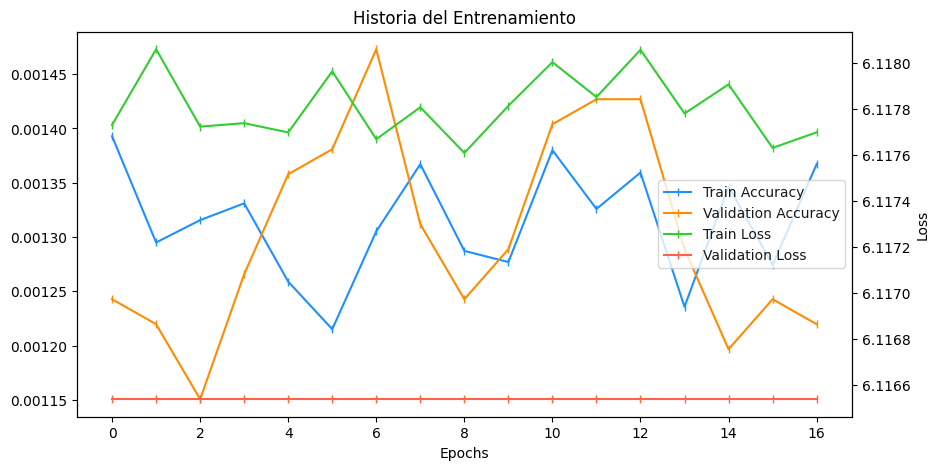

In [386]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_metric_history, label='Train Accuracy', marker='|', color='dodgerblue')  
ax1.plot(metric_history, label='Validation Accuracy', marker='|', color='darkorange') 
ax1.set_xlabel('Epochs')
ax1.tick_params(axis='y')
ax1.set_title('Historia del Entrenamiento')
ax2 = ax1.twinx()
ax2.plot(train_loss_history, label='Train Loss', marker='|', color='limegreen')  
ax2.plot(valid_loss_history, label='Validation Loss', marker='|', color='tomato') 
ax2.set_ylabel('Loss')
ax2.tick_params(axis='y')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines + lines2, labels + labels2, loc='center right')  # Leyenda en el centro derecho

for text in legend.get_texts():
    text.set_alpha(0.9)  

plt.show()

La implementación del modelo no logra ajustarce bien a los datos, estos modelos funcionan mejor cuando el conjunto de entrenamiento es un corpus pequeño, en este caso es demasiado grande para que el modelo puede entender la estructura que hy en el lenguage del corpus.Tambien considerando ventanas de tamaño mas grandes podemos llegar a mejorar pero el tiempo de entrenamiento aumenta. 

### **Gernerar texto** 

In [387]:
best_model = CharNLM_Bengio(args)
bets_model_path = r'model_char/model_best.pt'
best_model.load_state_dict(torch.load(bets_model_path)['state_dict'])
best_model.eval()

C:\Users\ericl\AppData\Local\Temp\ipykernel_29064\1259803162.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(bets_model_path)['stat

CharNLM_Bengio(
  (Embedding): Embedding(424, 100)
  (fc1): Linear(in_features=500, out_features=200, bias=True)
  (drop1): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=200, out_features=424, bias=False)
)

In [451]:
def parse_text(text, tokenizador_caracter):
    '''Función para extraer los tokens (caracteres) del texto y sus IDs'''
    all_tokens = [char if char in CharNgram_data.char2id else '<unk>'\
                  for char in tokenizador_caracter(text)]
    token_ids = [CharNgram_data.char2id[token] for token in all_tokens]
    return all_tokens, token_ids


def sample_next_char(logits, temperature=1.0):
    '''Muestra el siguiente carácter a partir de los logits con una temperatura dada'''
    logits = np.asarray(logits).astype('float64')
    preds = logits / temperature 
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds)
    return np.argmax(probas)

def predic_next_token(model, token_ids, temperature=1.0):
    '''Predice el siguiente carácter a partir de la secuencia de IDs'''
    char_ids_tensor = torch.LongTensor(token_ids).unsqueeze(0)
    y_raw_pred = model(char_ids_tensor).squeeze(0).detach().numpy()
    y_pred = sample_next_char(y_raw_pred, temperature)
    return y_pred

def generate_text(model, initial_text, tokenizador, n_pred=100, temperature=1.0):
    '''Genera texto a nivel carácter a partir de un texto inicial'''
    all_tokens, window_char_ids = parse_text(initial_text, tokenizador)
    
    # Asegurarse de que la ventana tenga la longitud requerida (model.window_size)
    required_length = model.window_size
    if len(window_char_ids) < required_length:
        pad_id = CharNgram_data.char2id[CharNgram_data.SOS]
        window_char_ids = [pad_id] * (required_length - len(window_char_ids)) + window_char_ids
    elif len(window_char_ids) > required_length:
        window_char_ids = window_char_ids[-required_length:]
    
    for i in range(n_pred):
        y_pred = predic_next_token(model, window_char_ids, temperature)
        # Si el token predicho no esta en el diccionario, se asigna <unk>
        if y_pred in CharNgram_data.id2char:
            next_char = CharNgram_data.id2char[y_pred]
        else:
            next_char = CharNgram_data.UNK
        
        all_tokens.append(next_char)
        
        if next_char == CharNgram_data.EOS:
            break
        else:
            window_char_ids.pop(0)         # Eliminar el primer elemento
            window_char_ids.append(y_pred)   # Agregar el token predicho
    
    return ''.join(all_tokens)


In [450]:
tokenizador_caracter = CharNgram_data.char_tokenizer
initial_text = 'presidente'
print('-'*20)
print('Learned Embeddings')
print('-'*20)
generate_text(best_model, initial_text, tokenizador_caracter, n_pred=300, temperature=0.8)

--------------------
Learned Embeddings
--------------------


"presidente<unk>)<unk><unk><unk><s><unk><unk><unk><unk><unk>'<unk><unk><unk><unk><unk>f<unk><unk><unk>o🤬PI<unk>íx<unk><unk>G😠<unk><unk>8<unk><unk><unk><unk>j<unk><unk>d<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>ú<unk>ú<unk><unk>*<unk><unk><unk>Í<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>é<unk>#<unk><unk><unk><unk><unk>+<unk><unk>H<unk><unk><unk><unk><unk>.<unk>X</s>"

In [426]:
initial_text = 'hola '
print('-'*20)
print('Learned Embeddings')
print('-'*20
generate_text(best_model, initial_text, tokenizador_caracter, n_pred=300, temperature=1.0)

--------------------
Learned Embeddings
--------------------


'hola</s>'

In [436]:
initial_text = 'mexico '
print('-'*20)
print('Learned Embeddings')
print('-'*20)
generate_text(best_model, initial_text, tokenizador_caracter, n_pred=300, temperature=1)

--------------------
Learned Embeddings
--------------------


'mexicoBC<unk><unk><unk><unk><unk><unk><unk>1<unk><unk><unk><unk><unk><unk><unk><unk>Á<unk>😠<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>🖕3Qeg<unk><unk><unk>k<unk><unk><unk><unk><unk><unk><unk><unk>s<unk></s>'

El modelo es entrenado en un corpus muy grande y con un vocabulario muy corto por lo que no es bueno generando texto, si utilizamos un corpus o datos de entrenamiento mas cortos podemos llegar a generar palabras coherentes. 


### **Likelihood de una oración**

In [437]:
def log_likelihood_char(model, text, char_ngram_data):
    # Genera n-gramas a nivel carácter para el texto
    X, y = char_ngram_data.transform([text])
    # Descartamos los primeros (N-1) n-gramas para eliminar la influencia de los tokens de inicio (<s>)
    drop = char_ngram_data.N - 1
    X, y = X[drop:], y[drop:]
    # Convertir X a tensor. Cada fila corresponde a la ventana de entrada de tamaño (N-1)
    X = torch.LongTensor(X)
    
    # Calcula los logits y extrae las probabilidades
    logits = model(X).detach()
    probs = F.softmax(logits, dim=1).numpy()
    llh = np.sum([np.log(probs[i][w]) for i, w in enumerate(y)])
    return llh

In [438]:
# Ejemplo de uso:
llh = log_likelihood_char(best_model, "el gobierno es una bola de corruptos", CharNgram_data)
print("log likelihood:", llh)

log likelihood: -159.60376


In [439]:
llh = log_likelihood_char(best_model,"hola mundo pequeño snoopy" , CharNgram_data)
print("log likelihood: ", llh)

log likelihood:  -108.22409


In [440]:
llh = log_likelihood_char(best_model,"bola de qulitos" , CharNgram_data)
print("log likelihood: ", llh)

log likelihood:  -54.787994


In [441]:
llh = log_likelihood_char(best_model,"si pierde el america, valio ..." , CharNgram_data)
print("log likelihood: ", llh)

log likelihood:  -133.8067


In [442]:
llh = log_likelihood_char(best_model,"vale madres" , CharNgram_data)
print("log likelihood: ", llh)

log likelihood:  -36.90848


### **Estructura Morfológica**

In [443]:
from itertools import permutations

char_seq = "madres"
perms = {''.join(perm) for perm in permutations(char_seq)}

perm_with_prob = [(log_likelihood_char(best_model, text, CharNgram_data), text) for text in perms]
sorted_perms = sorted(perm_with_prob, reverse=True)

print('-' * 20)
print("Top 5 permutaciones morfológicas con mayor probabilidad:")
for p, t in sorted_perms[:5]:
    print(f"Log Likelihood: {p:.4f}, Texto: {t}")

print('-' * 20)
print("Top 5 permutaciones morfológicas con menor probabilidad:")
for p, t in sorted_perms[-5:]:
    print(f"Log Likelihood: {p:.4f}, Texto: {t}")

--------------------
Top 5 permutaciones morfológicas con mayor probabilidad:
Log Likelihood: -11.2904, Texto: sdmrae
Log Likelihood: -11.2924, Texto: maesrd
Log Likelihood: -11.3307, Texto: samrde
Log Likelihood: -11.3418, Texto: smrdae
Log Likelihood: -11.3433, Texto: msedar
--------------------
Top 5 permutaciones morfológicas con menor probabilidad:
Log Likelihood: -12.8630, Texto: edarms
Log Likelihood: -12.8716, Texto: aesrmd
Log Likelihood: -12.8899, Texto: eradms
Log Likelihood: -12.9783, Texto: ersamd
Log Likelihood: -13.0052, Texto: easrmd


### **Perplejidad**

In [452]:
val_perplexity = evaluate_perplexity(model, valid_loader, criterion, device)
print("Val Perplexity: {:.2f}".format(val_perplexity))

Val Perplexity: 453.29


La perplejidad es menor dado que estamos utilizando el nivel caracter para el modelo aunque su desempeño es muy bajo **acc: 0.0014**. 